# Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import curve_fit

import joblib

from sklearn.linear_model import SGDClassifier

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

import warnings


from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

from sklearn.model_selection import learning_curve


# Analysis and organization

In [2]:
# Carregar o arquivo
df = pd.read_csv('/home/jefferson/Documentos/MEUS TRABALHOS/artigo 4/scripts/data/dados_quantum_walk_T_100_50.csv')

# Visualizar as primeiras linhas
df.head()

,delta_theta,IPR,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,...,prob_193,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202
0,0.000000,16.049482,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,0.000004,...,0.000140,0.0,0.000004,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0
1,0.010686,16.109290,0.0,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,0.000004,...,0.000146,0.0,0.000004,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0.0
2,0.021371,17.274234,0.0,1.693602e-13,0.0,1.838433e-10,0.0,4.131376e-08,0.0,0.000003,...,0.000119,0.0,0.000003,0.0,4.131376e-08,0.0,1.838433e-10,0.0,1.693602e-13,0.0
3,0.032057,17.394967,0.0,3.021244e-13,0.0,3.120592e-10,0.0,6.652273e-08,0.0,0.000005,...,0.000170,0.0,0.000005,0.0,6.652273e-08,0.0,3.120592e-10,0.0,3.021244e-13,0.0
4,0.042743,21.982325,0.0,2.373574e-13,0.0,2.485749e-10,0.0,5.372293e-08,0.0,0.000004,...,0.000141,0.0,0.000004,0.0,5.372293e-08,0.0,2.485749e-10,0.0,2.373574e-13,0.0


In [3]:
# Seleciona as colunas e mantém como um DataFrame, mas colocando values ele cria uma nova matriz
df_probs = df.filter(like='prob_')
df_probs.head()

,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,...,prob_193,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202
0,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,0.000004,0.0,0.000140,...,0.000140,0.0,0.000004,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0
1,0.0,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,0.000004,0.0,0.000146,...,0.000146,0.0,0.000004,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0.0
2,0.0,1.693602e-13,0.0,1.838433e-10,0.0,4.131376e-08,0.0,0.000003,0.0,0.000119,...,0.000119,0.0,0.000003,0.0,4.131376e-08,0.0,1.838433e-10,0.0,1.693602e-13,0.0
3,0.0,3.021244e-13,0.0,3.120592e-10,0.0,6.652273e-08,0.0,0.000005,0.0,0.000170,...,0.000170,0.0,0.000005,0.0,6.652273e-08,0.0,3.120592e-10,0.0,3.021244e-13,0.0
4,0.0,2.373574e-13,0.0,2.485749e-10,0.0,5.372293e-08,0.0,0.000004,0.0,0.000141,...,0.000141,0.0,0.000004,0.0,5.372293e-08,0.0,2.485749e-10,0.0,2.373574e-13,0.0


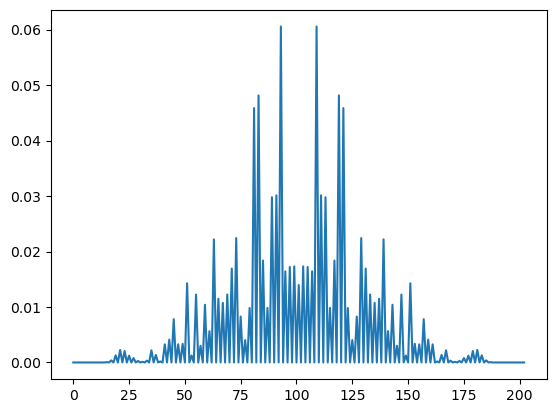

In [4]:
plt.plot(df_probs.iloc[25].values)
plt.show()

List of IPR

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


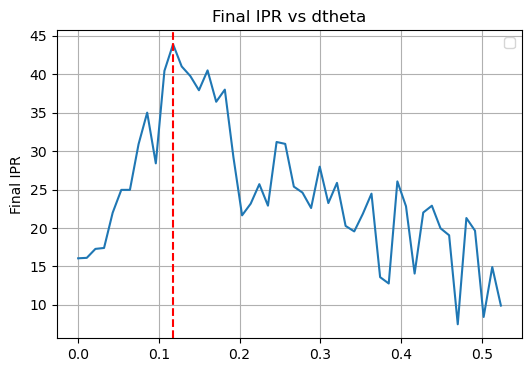

In [5]:
IPR_list = df['IPR']

plt.figure(figsize=(6,4))
plt.plot(df['delta_theta'].values[:2500],df['IPR'].values[:2500])
plt.axvline(x=df['delta_theta'].iloc[np.argmax(IPR_list)], color='red', linestyle='--')
plt.title('Final IPR vs dtheta')
plt.ylabel('Final IPR')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
df.iloc[np.argmax(IPR_list)]
critical_exp = df['delta_theta'].iloc[np.argmax(IPR_list)]
critical_exp

0.1175425822771691

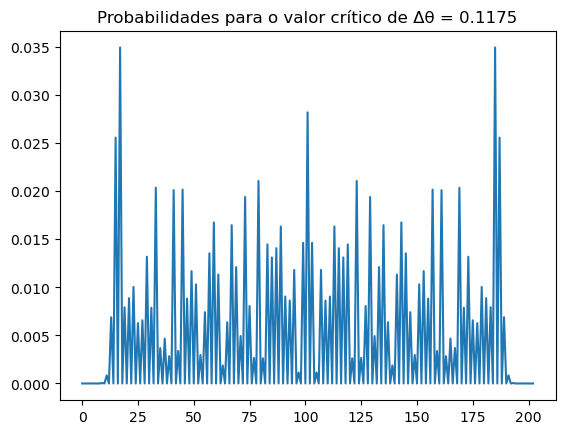

In [7]:
plt.plot(df_probs.iloc[np.argmax(IPR_list)].values)
plt.title(f'Probabilidades para o valor crítico de Δθ = {critical_exp:.4f}')
plt.show()

Data separation for training: Label 0 is assigned to delocalized states (ranging from $0$ to $50$), and Label 1 to localized states (ranging from $200$ to $250$).

In [8]:
# Assigning labels to the training data

n_total = len(df)
ponto_de_corte = np.argmax(df['IPR'].values)  # Onde os 0s terminam e os 1s começam

# Cria a coluna: metade 0, metade 1
coluna_rotulo = np.concatenate([
    np.zeros(ponto_de_corte), 
    np.ones(n_total - ponto_de_corte)
])

# Adiciona a coluna ao DataFrame e garanto que seja inteira
df_probs['label'] = coluna_rotulo.astype(int)

/tmp/ipykernel_19182/2789398605.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_probs['label'] = coluna_rotulo.astype(int)


Pego os 50 primeiros deslocalizados e depois mais 50 localizados

In [9]:
df_training = df_probs.iloc[np.r_[0:8, 42:50]]

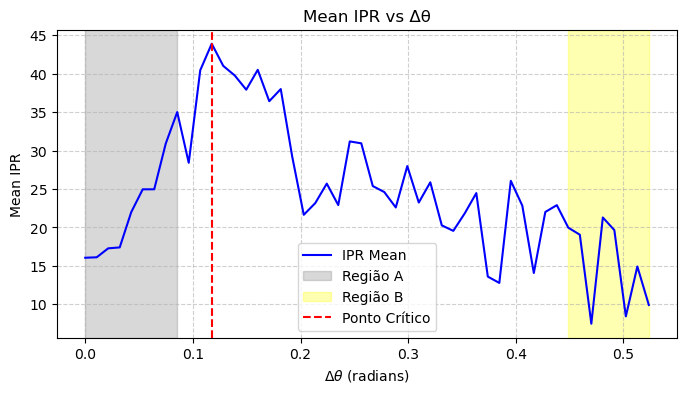

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(df['delta_theta'].values,df['IPR'].values, label='IPR Mean', color='blue', zorder=2)

# Colorindo o primeiro intervalo [0:300]
plt.axvspan(df['delta_theta'].values[:][0], df['delta_theta'].values[:][8], 
            color='gray', alpha=0.3, label='Região A')

# Colorindo o segundo intervalo [700:1000]
# Nota: se o índice for 1000, use 999 para não estourar o limite do array
plt.axvspan(df['delta_theta'].values[:][42], df['delta_theta'].values[:][49], 
            color='yellow', alpha=0.3, label='Região B')

plt.title('Mean IPR vs Δθ')
plt.xlabel(r'$\Delta\theta$ (radians)')
plt.ylabel('Mean IPR')
plt.axvline(x=critical_exp, color='red', linestyle='--', label='Ponto Crítico')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

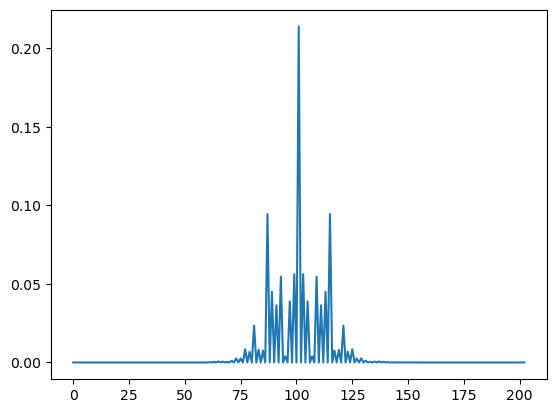

In [11]:
plt.plot(df_probs.iloc[49].values[:-1])
plt.show()

In [12]:
len(df_probs.iloc[49].values)

204

Spliting 80% for training data and 20% for testing model's accuracy. Choice made radomly.

In [13]:
# 1. Definimos o Seed para reprodutibilidade
seed = 42

# 2. Criamos o set de Treino (80%)
df_train = df_training.sample(frac=0.8, random_state=seed)

# 3. Criamos o set de Teste (o que sobrou)
# O .drop() remove as linhas que já foram para o treino
df_test = df_training.drop(df_train.index)

# NN MLP

In [14]:
def sigmoide_automatica(x, y):
    # --- AUTO-CHUTE (O segredo para não falhar) ---
    # Centro (x0): Onde o y está mais próximo de 0.5
    x0_chute = x[np.argmin(np.abs(y - 0.5))]
    
    # Inclinação (k): Estimada pela diferença entre os extremos
    # Se a curva sobe, k é positivo. Se desce, k é negativo.
    k_chute = (y[-1] - y[0]) / (x[-1] - x[0]) * 4 

    # Função modelo: Sigmóide padrão
    def f(x, k, x0):
        return 1 / (1 + np.exp(-k * (x - x0)))

    # Ajuste com os chutes calculados automaticamente
    popt, pcov = curve_fit(f, x, y, p0=[k_chute, x0_chute])
    
    return popt # Retorna [k, x0]

In [15]:
X_train = df_train.drop(columns=['label']).values
y_train = df_train['label'].values

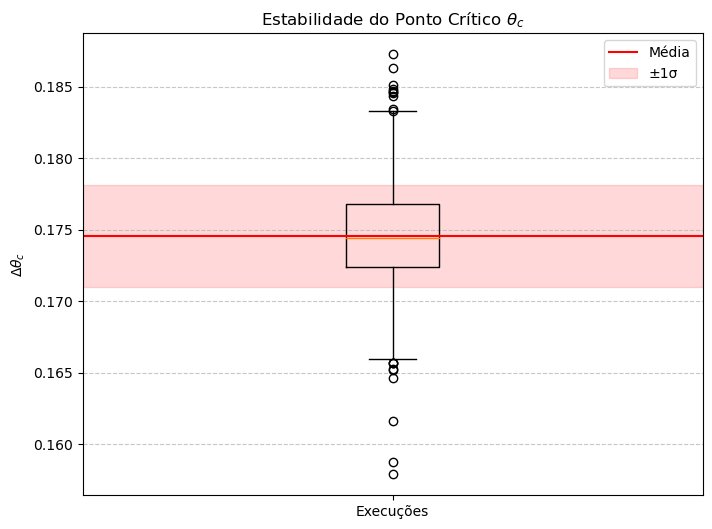

In [16]:
warnings.filterwarnings("ignore")

# Configuração
n_execucoes = 1000
pontos_criticos_p = []

for i in range(n_execucoes):
    mlp = MLPClassifier(
        hidden_layer_sizes=(400, 200, 100, 50),
        activation='relu',
        solver='adam',
        alpha=0.001,
        max_iter=1000
    )

    mlp.fit(X_train, y_train)

    probs = mlp.predict_proba(df_probs.drop(columns=['label']).values[:2500, :])
    delta_theta_trans = df.filter(like='delta_theta').iloc[:2500].values.flatten()
    prob_delocalized = probs[:, 0]

    try:
        res_fit = sigmoide_automatica(delta_theta_trans, prob_delocalized)
        x0 = res_fit[1]
    except Exception:
        x0 = 0

    pontos_criticos_p.append(x0)

# Estatísticas
media = np.mean(pontos_criticos_p)
desvio = np.std(pontos_criticos_p)

# Plot
plt.figure(figsize=(8, 6))

# Boxplot (um único)
plt.boxplot(pontos_criticos_p, patch_artist=False)

# Média (linha horizontal)
plt.axhline(media, color='red', linestyle='-', linewidth=1.5, label='Média')

# Banda de desvio padrão
plt.axhspan(media - desvio, media + desvio, 
            color='red', alpha=0.15, label='±1σ')

# Estética
plt.title("Estabilidade do Ponto Crítico " + r"$\theta_c$")
plt.ylabel(r"$\Delta\theta_c$")
plt.xticks([1], ['Execuções'])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.show()

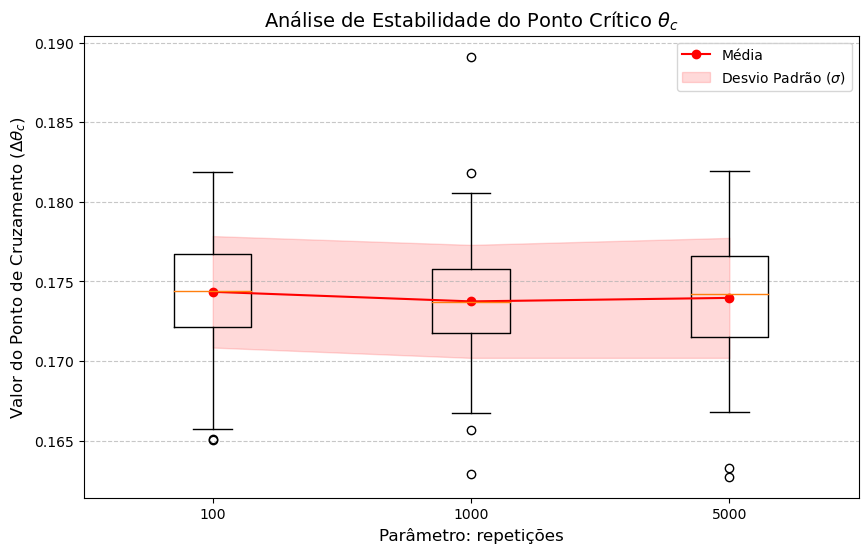

In [18]:
warnings.filterwarnings("ignore")

# Configurações do Teste
n_execucoes = 100  # Quantas vezes rodar cada parâmetro para gerar a estatística
parametros_teste = [100, 1000, 5000]  # Valores de n_iter_no_change para testar
resultados_finais = []

for p in parametros_teste:
    pontos_criticos_p = []
    #print(f"Testando n_iter_no_change = {p}...")
    
    for i in range(n_execucoes):
        # 1. Treinar modelo (Sem seed fixa para capturar a variância real)
        mlp = MLPClassifier(hidden_layer_sizes=(400,200,100,50),
                             activation='relu',
                             solver='adam',
                             alpha=0.001,
                             max_iter=1000
            )
        mlp.fit(X_train, y_train)
        
        # 2. Obter as probabilidades para os dados de transição
        probs = mlp.predict_proba(df_probs.drop(columns=['label']).values[:2500, :])
        delta_theta_trans = df.filter(like='delta_theta').iloc[:2500].values.flatten()
        prob_delocalized = probs[:, 0]

        # 3. Tentativa de Fitting com salvamento de 0 em caso de erro
        try:
            # Tenta o ajuste
            res_fit = sigmoide_automatica(delta_theta_trans, prob_delocalized)
            x0 = res_fit[1]
        except Exception:
            # Se der erro (maxfev, etc), salva 0 para indicar "instabilidade total"
            x0 = 0
        
        pontos_criticos_p.append(x0)
        
    resultados_finais.append(pontos_criticos_p)

# 1. Preparação dos dados estatísticos
# Assumindo que resultados_finais é uma lista de arrays/listas
medias = [np.mean(grupo) for grupo in resultados_finais]
desvios = [np.std(grupo) for grupo in resultados_finais]
x = np.arange(1, len(parametros_teste) + 1) # O boxplot usa índices 1, 2, 3...

plt.figure(figsize=(10, 6))

# 2. Desenhar o Boxplot original
# patch_artist=True permite colorir as caixas se desejar
plt.boxplot(resultados_finais, labels=parametros_teste, patch_artist=False)

# 3. Sobrepor a linha da Média
plt.plot(x, medias, color='red', marker='o', label='Média', linewidth=1.5)

# 4. Adicionar o sombreamento do Desvio Padrão
# O alpha define a transparência para não cobrir o boxplot
plt.fill_between(x, 
                 np.array(medias) - np.array(desvios), 
                 np.array(medias) + np.array(desvios), 
                 color='red', alpha=0.15, label='Desvio Padrão ($\sigma$)')

# 5. Estilização acadêmica
plt.title("Análise de Estabilidade do Ponto Crítico " + r"$\theta_c$", fontsize=14)
plt.xlabel("Parâmetro: repetições", fontsize=12)
plt.ylabel(r"Valor do Ponto de Cruzamento ($\Delta\theta_c$)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.show()

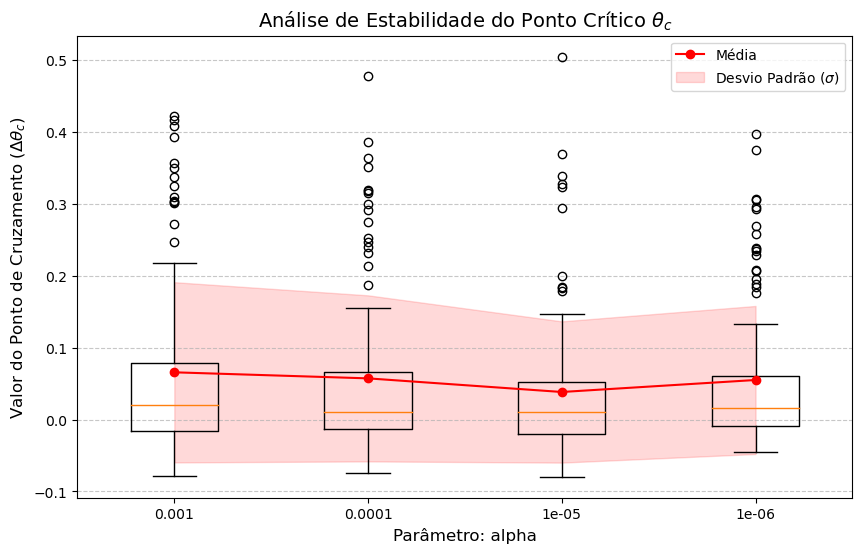

In [17]:
warnings.filterwarnings("ignore")

# Configurações do Teste
n_execucoes = 100  # Quantas vezes rodar cada parâmetro para gerar a estatística
parametros_teste = [0.001, 0.0001, 0.00001, 0.000001]  # Valores de alpha para testar
resultados_finais = []

for p in parametros_teste:
    pontos_criticos_p = []
    #print(f"Testando n_iter_no_change = {p}...")
    
    for i in range(n_execucoes):
        # 1. Treinar modelo (Sem seed fixa para capturar a variância real)
        mlp = MLPClassifier(hidden_layer_sizes=(400,200,100,50),
                             activation='relu',
                             solver='adam',
                             alpha=p,
                             max_iter=1000,
                             tol = 0.00001,
                             early_stopping=True,
                             n_iter_no_change=100
            )
        mlp.fit(X_train, y_train)
        
        # 2. Obter as probabilidades para os dados de transição
        probs = mlp.predict_proba(df_probs.drop(columns=['label']).values[:2500, :])
        delta_theta_trans = df.filter(like='delta_theta').iloc[:2500].values.flatten()
        prob_delocalized = probs[:, 0]

        # 3. Tentativa de Fitting com salvamento de 0 em caso de erro
        try:
            # Tenta o ajuste
            res_fit = sigmoide_automatica(delta_theta_trans, prob_delocalized)
            x0 = res_fit[1]
        except Exception:
            # Se der erro (maxfev, etc), salva 0 para indicar "instabilidade total"
            x0 = 0
        
        pontos_criticos_p.append(x0)
        
    resultados_finais.append(pontos_criticos_p)

# 1. Preparação dos dados estatísticos
# Assumindo que resultados_finais é uma lista de arrays/listas
medias = [np.mean(grupo) for grupo in resultados_finais]
desvios = [np.std(grupo) for grupo in resultados_finais]
x = np.arange(1, len(parametros_teste) + 1) # O boxplot usa índices 1, 2, 3...

plt.figure(figsize=(10, 6))

# 2. Desenhar o Boxplot original
# patch_artist=True permite colorir as caixas se desejar
plt.boxplot(resultados_finais, labels=parametros_teste, patch_artist=False)

# 3. Sobrepor a linha da Média
plt.plot(x, medias, color='red', marker='o', label='Média', linewidth=1.5)

# 4. Adicionar o sombreamento do Desvio Padrão
# O alpha define a transparência para não cobrir o boxplot
plt.fill_between(x, 
                 np.array(medias) - np.array(desvios), 
                 np.array(medias) + np.array(desvios), 
                 color='red', alpha=0.15, label='Desvio Padrão ($\sigma$)')

# 5. Estilização acadêmica
plt.title("Análise de Estabilidade do Ponto Crítico " + r"$\theta_c$", fontsize=14)
plt.xlabel("Parâmetro: alpha", fontsize=12)
plt.ylabel(r"Valor do Ponto de Cruzamento ($\Delta\theta_c$)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.show()

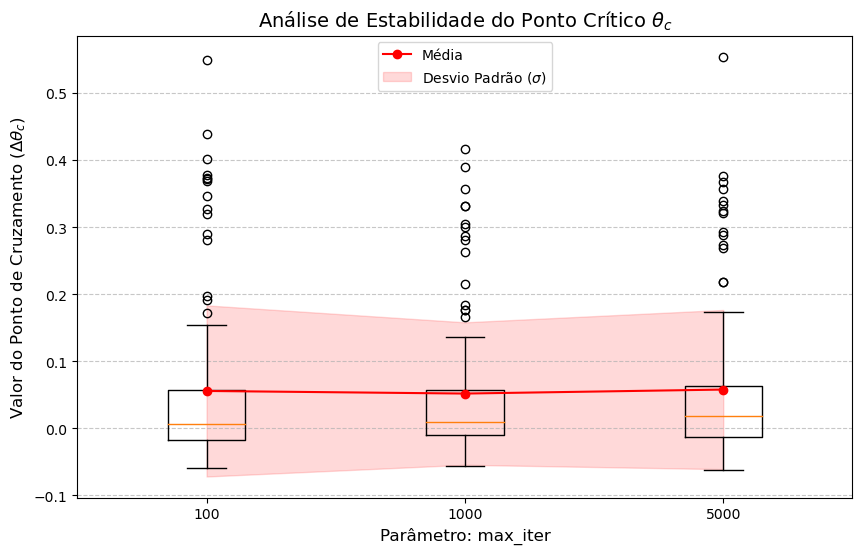

In [20]:
warnings.filterwarnings("ignore")

# Configurações do Teste
n_execucoes = 100  # Quantas vezes rodar cada parâmetro para gerar a estatística
parametros_teste = [100, 1000, 5000]  # Valores de n_iter_no_change para testar
resultados_finais = []

for p in parametros_teste:
    pontos_criticos_p = []
    #print(f"Testando n_iter_no_change = {p}...")
    
    for i in range(n_execucoes):
        # 1. Treinar modelo (Sem seed fixa para capturar a variância real)
        mlp = MLPClassifier(hidden_layer_sizes=(400,200,100,50),
                             activation='relu',
                             solver='adam',
                             alpha=0.001,
                             max_iter=p,
                             tol = 0.000001,
                             early_stopping=True,
                             n_iter_no_change=100
            )
        mlp.fit(X_train, y_train)
        
        # 2. Obter as probabilidades para os dados de transição
        probs = mlp.predict_proba(df_probs.drop(columns=['label']).values[:2500, :])
        delta_theta_trans = df.filter(like='delta_theta').iloc[:2500].values.flatten()
        prob_delocalized = probs[:, 0]

        # 3. Tentativa de Fitting com salvamento de 0 em caso de erro
        try:
            # Tenta o ajuste
            res_fit = sigmoide_automatica(delta_theta_trans, prob_delocalized)
            x0 = res_fit[1]
        except Exception:
            # Se der erro (maxfev, etc), salva 0 para indicar "instabilidade total"
            x0 = 0
        
        pontos_criticos_p.append(x0)
        
    resultados_finais.append(pontos_criticos_p)

# 1. Preparação dos dados estatísticos
# Assumindo que resultados_finais é uma lista de arrays/listas
medias = [np.mean(grupo) for grupo in resultados_finais]
desvios = [np.std(grupo) for grupo in resultados_finais]
x = np.arange(1, len(parametros_teste) + 1) # O boxplot usa índices 1, 2, 3...

plt.figure(figsize=(10, 6))

# 2. Desenhar o Boxplot original
# patch_artist=True permite colorir as caixas se desejar
plt.boxplot(resultados_finais, labels=parametros_teste, patch_artist=False)

# 3. Sobrepor a linha da Média
plt.plot(x, medias, color='red', marker='o', label='Média', linewidth=1.5)

# 4. Adicionar o sombreamento do Desvio Padrão
# O alpha define a transparência para não cobrir o boxplot
plt.fill_between(x, 
                 np.array(medias) - np.array(desvios), 
                 np.array(medias) + np.array(desvios), 
                 color='red', alpha=0.15, label='Desvio Padrão ($\sigma$)')

# 5. Estilização acadêmica
plt.title("Análise de Estabilidade do Ponto Crítico " + r"$\theta_c$", fontsize=14)
plt.xlabel("Parâmetro: max_iter", fontsize=12)
plt.ylabel(r"Valor do Ponto de Cruzamento ($\Delta\theta_c$)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.show()